<a href="https://colab.research.google.com/github/lankelasharanya04-crypto/datascience_tasks/blob/main/ZOMATO_BANGALORE_DATA_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**importing libraries**

###objectives:
To perform Exploratory Data Analysis (EDA) on the Zomato Bangalore dataset and generate
meaningful business insights using Python.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**reading the data and displaying first 5 rows**


In [ ]:
df = pd.read_excel("zomato_rest_data.xlsx")
df.head()

,Unnamed: 0,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


**displaying shape of the dataset**


In [ ]:
df.shape

(51717, 18)

**listing the column names**

In [ ]:
df.columns

Index(['Unnamed: 0', 'url', 'address', 'name', 'online_order', 'book_table',
       'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked',
       'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

**checking the datatypes of those columns**

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Unnamed: 0                   51717 non-null  int64 
 1   url                          51717 non-null  object
 2   address                      51717 non-null  object
 3   name                         51717 non-null  object
 4   online_order                 51717 non-null  object
 5   book_table                   51717 non-null  object
 6   rate                         43942 non-null  object
 7   votes                        51717 non-null  int64 
 8   phone                        50509 non-null  object
 9   location                     51696 non-null  object
 10  rest_type                    51490 non-null  object
 11  dish_liked                   23639 non-null  object
 12  cuisines                     51672 non-null  object
 13  approx_cost(for two people)  51

**identifying the missing values**

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
phone,1208
location,21


**dropping phone column and url column  and some unnecessary columns for now because they are not useful**

In [ ]:
df = df.drop(['phone', 'url','Unnamed: 0','address','location','reviews_list','menu_item','rest_type'], axis=1)

In [ ]:
#renaming columns to make everything easier
df = df.rename(columns={
    'listed_in(type)': 'rest_type',
    'listed_in(city)': 'location'
})

**checking the columns after removing the phone and url columns**


In [ ]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'dish_liked',
       'cuisines', 'approx_cost(for two people)', 'rest_type', 'location'],
      dtype='object')

**dropping duplicates if any present **


In [ ]:
df = df.drop_duplicates()
df.shape

(51577, 10)

# Handle missing values appropriately


**handling missing values in rate column**

In [ ]:
df['rate'].unique() #checking unique values

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [ ]:
# Replace "NEW" values with NaN (missing values)
df['rate'] = df['rate'].replace("NEW", np.nan)

# Replace "-" values with NaN
df['rate'] = df['rate'].replace("-", np.nan)

# Remove "/5" from rating values
df['rate'] = df['rate'].str.strip("/5")

# Convert rating column to float datatype
df['rate'] = df['rate'].astype(float)

# Fill missing rating values with the rounded mean rating
df['rate'] = df['rate'].fillna(round(df['rate'].mean()))

In [ ]:
df['rate'].unique()  #checking unique values

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, 2.9, 2.6, 3.4, 2. , 2.7, 4.7, 2.4, 2.2, 2.3, 4.8, 3.5,
       2.5, 4.5, 4.9, 2.1, 1.8])

In [ ]:
df.isnull().sum() #checking missing values

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
dish_liked,27982
cuisines,45
approx_cost(for two people),344
rest_type,0
location,0


In [ ]:
df['approx_cost(for two people)'].unique()   #checking unique values

array(['800', '300', '600', '700', '550', '500', '450', '650', '400',
       '900', '200', '750', '150', '850', '100', '1,200', '350', '250',
       '950', '1,000', '1,500', '1,300', '199', '80', '1,100', '160',
       '1,600', '230', '130', '50', '190', '1,700', nan, '1,400', '180',
       '1,350', '2,200', '2,000', '1,800', '1,900', '330', '2,500',
       '2,100', '3,000', '2,800', '3,400', '40', '1,250', '3,500',
       '4,000', '2,400', '2,600', '120', '1,450', '469', '70', '3,200',
       '60', '560', '240', '360', '6,000', '1,050', '2,300', '4,100',
       '5,000', '3,700', '1,650', '2,700', '4,500', '140'], dtype=object)

In [ ]:
# Remove commas from cost values (e.g., "1,200" → "1200")
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '')

# Convert cost column to float datatype
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(float)

# Fill missing values with the mean cost
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].fillna(
    df['approx_cost(for two people)'].mean()
)

# Convert float values to integer (since cost is whole number)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(int)

# Display unique cost values to verify cleaning
df['approx_cost(for two people)'].unique()

array([ 800,  300,  600,  700,  550,  500,  450,  650,  400,  900,  200,
        750,  150,  850,  100, 1200,  350,  250,  950, 1000, 1500, 1300,
        199,   80, 1100,  160, 1600,  230,  130,   50,  190, 1700,  555,
       1400,  180, 1350, 2200, 2000, 1800, 1900,  330, 2500, 2100, 3000,
       2800, 3400,   40, 1250, 3500, 4000, 2400, 2600,  120, 1450,  469,
         70, 3200,   60,  560,  240,  360, 6000, 1050, 2300, 4100, 5000,
       3700, 1650, 2700, 4500,  140])

In [ ]:
df = df.rename(columns={
  'approx_cost(for two people)': 'cost_for_two'
})   #renaming colums according to our liking

In [ ]:
df['dish_liked'].unique()

array(['Pasta, Lunch Buffet, Masala Papad, Paneer Lajawab, Tomato Shorba, Dum Biryani, Sweet Corn Soup',
       'Momos, Lunch Buffet, Chocolate Nirvana, Thai Green Curry, Paneer Tikka, Dum Biryani, Chicken Biryani',
       'Churros, Cannelloni, Minestrone Soup, Hot Chocolate, Pink Sauce Pasta, Salsa, Veg Supreme Pizza',
       ...,
       'Noodles, Chicken Noodle, Momos, American Chopsuey, Salad, Manchow Soup, Manchurian',
       'Chicken Quesadilla, Naan, Breakfast Buffet, Cheesecake, Cocktails, Lunch Buffet, Biryani',
       'Biryani, Andhra Meal'], dtype=object)

In [ ]:
 #Fill missing values in 'dish_liked' column with the most frequent dish
# mode()[0] returns the most commonly occurring value in the column
df['dish_liked'] = df['dish_liked'].fillna(df['dish_liked'].mode()[0])

In [ ]:
df.isnull().sum()

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
dish_liked,0
cuisines,45
cost_for_two,0
rest_type,0
location,0


In [ ]:
# Fill missing values in 'cuisines' column with the most frequent cuisine
# mode()[0] returns the most commonly occurring cuisine in the dataset
df['cuisines'] = df['cuisines'].fillna(df['cuisines'].mode()[0])

In [ ]:
df.isnull().sum()

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
dish_liked,0
cuisines,0
cost_for_two,0
rest_type,0
location,0


In [ ]:
df.head()

,name,online_order,book_table,rate,votes,dish_liked,cuisines,cost_for_two,rest_type,location
0,Jalsa,Yes,Yes,4.1,775,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,"Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Masala Dosa,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,No,3.8,166,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet,Banashankari


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51577 entries, 0 to 51716
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          51577 non-null  object 
 1   online_order  51577 non-null  object 
 2   book_table    51577 non-null  object 
 3   rate          51577 non-null  float64
 4   votes         51577 non-null  int64  
 5   dish_liked    51577 non-null  object 
 6   cuisines      51577 non-null  object 
 7   cost_for_two  51577 non-null  int64  
 8   rest_type     51577 non-null  object 
 9   location      51577 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 4.3+ MB


# Univariate Analysis


**Top 5 locations with highest number of restaurants**


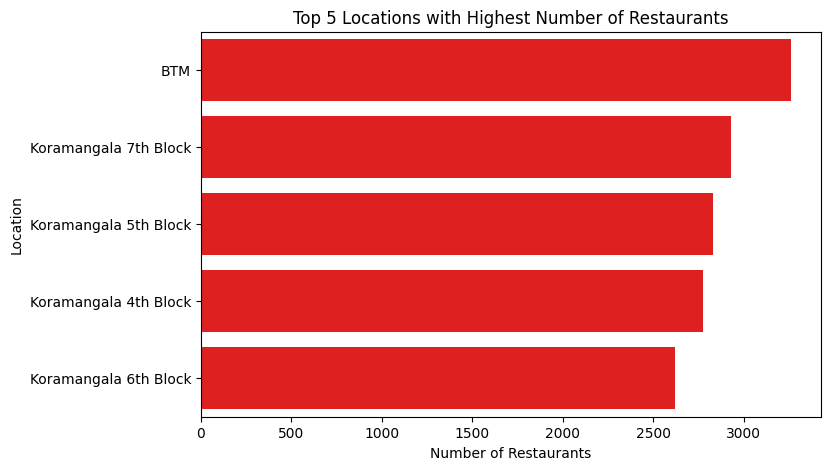

In [ ]:
#Counts how many restaurants exist in each location and select top 5
top_locations = df['location'].value_counts().head(5)
#Sets plot size to 8 (width) × 5 (height).
plt.figure(figsize=(8,5))
#Creating a horizontal bar chart.
# X-axis → number of restaurants
# Y-axis → location names
sns.barplot(x=top_locations.values, y=top_locations.index,color='red')
plt.title("Top 5 Locations with Highest Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("Location")   #labelling
#displaying
plt.show()

## highest location is of BTM followed by Koramangala blocks

**Distribution of restaurant ratings**

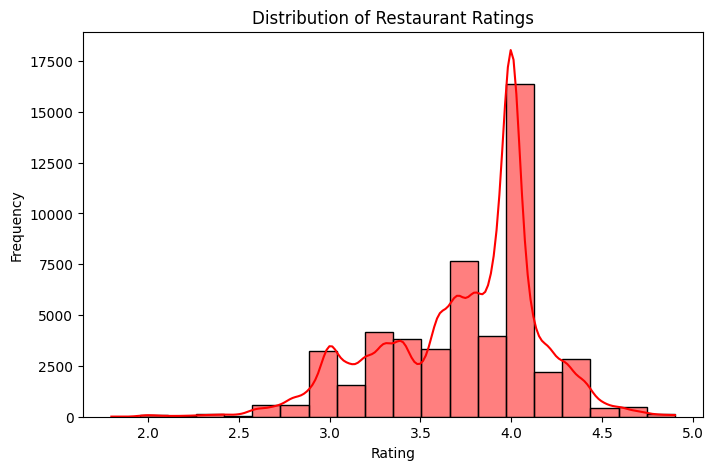

In [ ]:
# Creating a new figure with specified width and height
plt.figure(figsize=(8,5))
# Plotting histogram of restaurant ratings
# bins=20 divides the data into 20 intervals
# kde=True adds a smooth density curve
# color='red' sets the histogram color to red
sns.histplot(df['rate'], bins=20, kde=True, color='red')
# Adding title to the graph
plt.title("Distribution of Restaurant Ratings")
# Labeling the X-axis
plt.xlabel("Rating")
# Labeling the Y-axis
plt.ylabel("Frequency")
# Display the plot
plt.show()

mostly between 4-5 rating have highest cost

**Percentage of restaurants offering online orders**

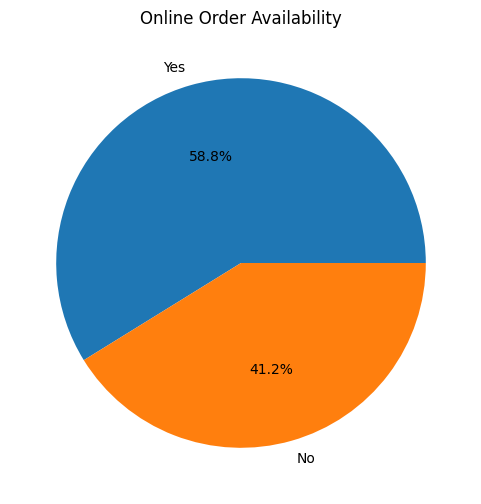

In [ ]:
# Counting the number of restaurants that offer and do not offer online ordering
online_counts = df['online_order'].value_counts()
# Creating a square figure for better pie chart visualization
plt.figure(figsize=(6,6))
# Creating a pie chart
plt.pie(online_counts, labels=online_counts.index,autopct='%1.1f%%')
# Adding the title to the chart
plt.title("Online Order Availability")
# Displaying the plot
plt.show()

## both have equally likely polls

** Distribution of average cost for two**

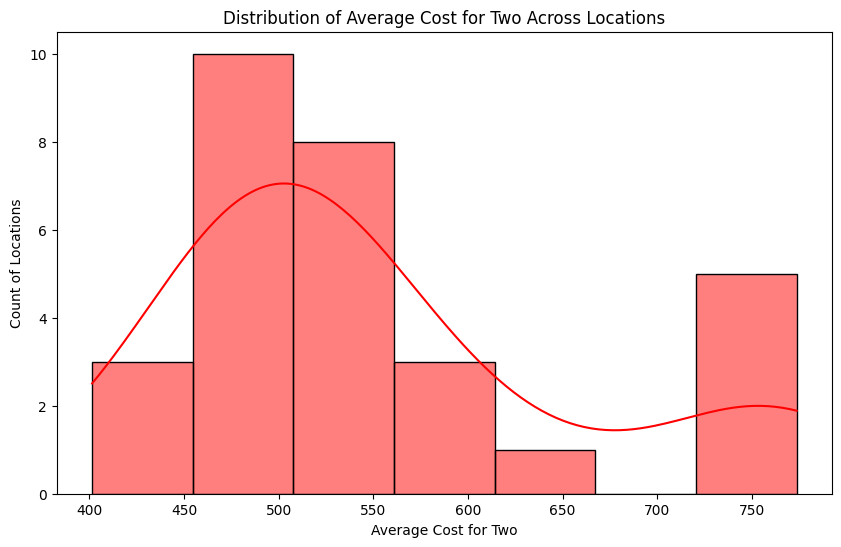

In [ ]:
# Calculating average cost for two across each location
df1 = df.groupby('location')['cost_for_two'].mean()

plt.figure(figsize=(10,6))

# Creating histogram to show distribution of average cost values
sns.histplot(df1, kde=True, color="red")

# Adding title and axis labels
plt.title("Distribution of Average Cost for Two Across Locations")
plt.xlabel("Average Cost for Two")
plt.ylabel("Count of Locations")

# Displaying the plot
plt.show()

more locations have higher avg cost

#Task 3: Bivariate Analysis

Rating vs Cost

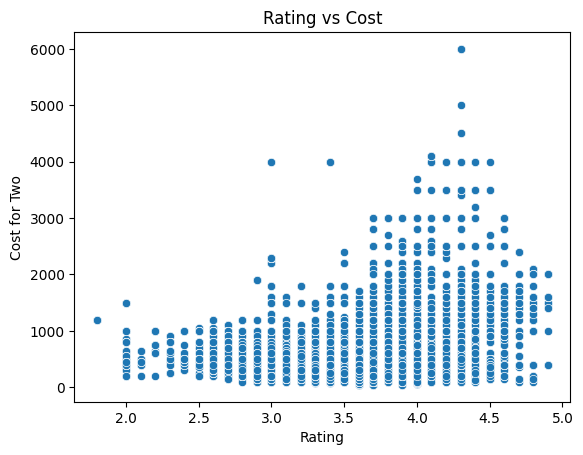

In [ ]:
#plt.figure(figsize=(8,5))
sns.scatterplot(x=df['rate'], y=df['cost_for_two'])
plt.title("Rating vs Cost")
plt.ylabel("Cost for Two")
plt.xlabel("Rating")
plt.show()


## has rating increases cost also increases

**Rating vs Online Order**

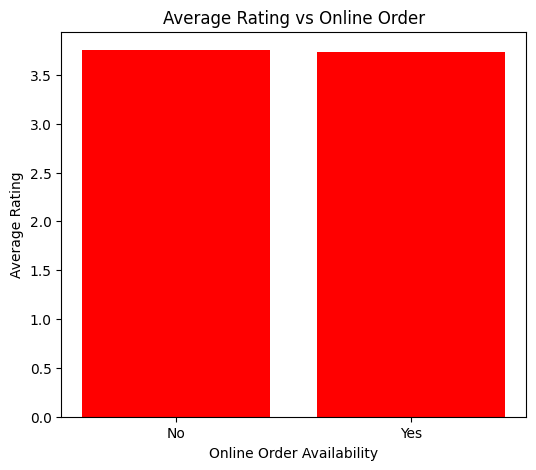

In [ ]:
# Group by online_order and calculate average rating
data = df.groupby('online_order')['rate'].mean().reset_index()

# Create figure
plt.figure(figsize=(6,5))

# Create bar graph
plt.bar(data['online_order'], data['rate'], color='red')

# Add title and labels
plt.title("Average Rating vs Online Order")
plt.xlabel("Online Order Availability")
plt.ylabel("Average Rating")

# Display plot
plt.show()

## both prefer online and offline

**Votes vs Rating**

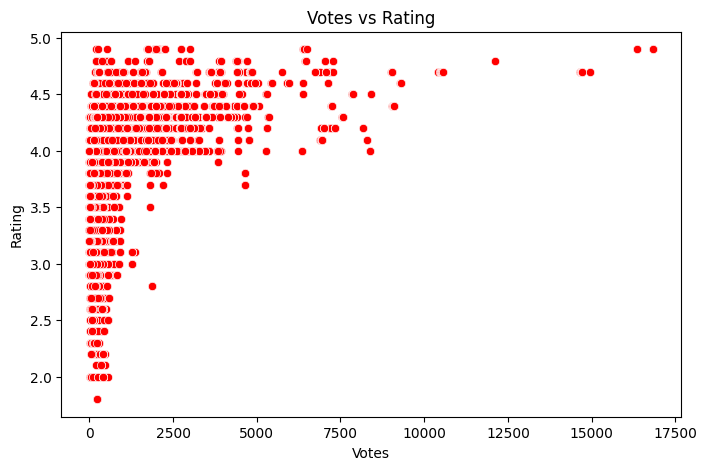

In [ ]:
# Create a new figure with specified size
plt.figure(figsize=(8,5))
# Create scatter plot to show relationship between votes and rating
# x='votes' → number of customer votes
# y='rate' → restaurant rating
# color='red' → sets point color
sns.scatterplot(x='votes', y='rate', data=df, color='red')
# Add title
plt.title("Votes vs Rating")
# Label axes
plt.xlabel("Votes")
plt.ylabel("Rating")
# Display the plot
plt.show()

## no correlation can be observed

#Task 4: Business Insights & Recommendations

###Does higher cost lead to higher ratings?
yes,as cost increases it is leading to higher ratings

###Does offering online order impact ratings?
no, rating is almost same for having online rating annd non online outlets , so it doesnot matter .

###Which location appears highly competitive?
btm is more competitive , because its having more number of restraunts

###Where would you recommend opening a new restaurant?
new bel road,banashankari,rajajinagar ,these three would be great because they have low competition.

In [ ]:
df.to_csv("zomato_cleaned_dataset.csv", index=False)
from google.colab import files
files.download("zomato_cleaned_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>